In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

df = pd.read_excel('cleaned_dataset_zahrarahgosha84.xlsx')
print('تعداد مشتریان:', len(df))
df.head()

تعداد مشتریان: 60


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [2]:
# نمره تازگی: هرچی last_purchase_days کمتر باشه، نمره بالاتر (4 بهترین)
df['R_score'] = pd.qcut(df['last_purchase_days'], 4, labels=[4, 3, 2, 1]).astype(int)

# نمره فراوانی و ارزش پولی: هرچی بیشتر بهتر
df['F_score'] = pd.qcut(df['purchase_count'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
df['M_score'] = pd.qcut(df['total_spending'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)

df['RFM_total'] = df['R_score'] + df['F_score'] + df['M_score']

def segment_customer(row):
    if row['RFM_total'] >= 10:
        return 'مشتریان طلایی'
    elif row['RFM_total'] >= 7:
        return 'وفادار'
    elif row['R_score'] <= 1:
        return 'در خطر ریزش'
    else:
        return 'کم‌ارزش'

df['segment'] = df.apply(segment_customer, axis=1)
df[['customer_id', 'city', 'last_purchase_days', 'purchase_count', 'total_spending',
    'R_score', 'F_score', 'M_score', 'RFM_total', 'segment']].head(10)

,customer_id,city,last_purchase_days,purchase_count,total_spending,R_score,F_score,M_score,RFM_total,segment
0,1001,Karaj,16,17,2066.01,4,2,2,8,وفادار
1,1002,Tehran,3,12,3917.64,4,2,3,9,وفادار
2,1003,Shiraz,22,21,1248.66,4,3,2,9,وفادار
3,1004,Mashhad,40,23,6121.45,4,3,4,11,مشتریان طلایی
4,1005,Isfahan,273,23,3899.42,2,3,3,8,وفادار
5,1006,Mashhad,205,35,3868.55,2,4,3,9,وفادار
6,1007,Rasht,298,29,2237.35,1,4,3,8,وفادار
7,1008,Rasht,195,3,1168.74,3,1,2,6,کم‌ارزش
8,1009,Karaj,232,34,11615.42,2,4,4,10,مشتریان طلایی
9,1010,Karaj,276,19,7241.47,1,3,4,8,وفادار


In [3]:
segment_summary = df.groupby('segment').agg(
    تعداد_مشتری=('customer_id', 'count'),
    مجموع_درآمد=('total_spending', 'sum'),
    میانگین_درآمد=('total_spending', 'mean'),
).sort_values('مجموع_درآمد', ascending=False)

segment_summary

,تعداد_مشتری,مجموع_درآمد,میانگین_درآمد
segment,,,
مشتریان طلایی,14,98650.30,7046.450000
وفادار,28,85808.26,3064.580714
در خطر ریزش,8,9218.66,1152.332500
کم‌ارزش,10,8308.51,830.851000


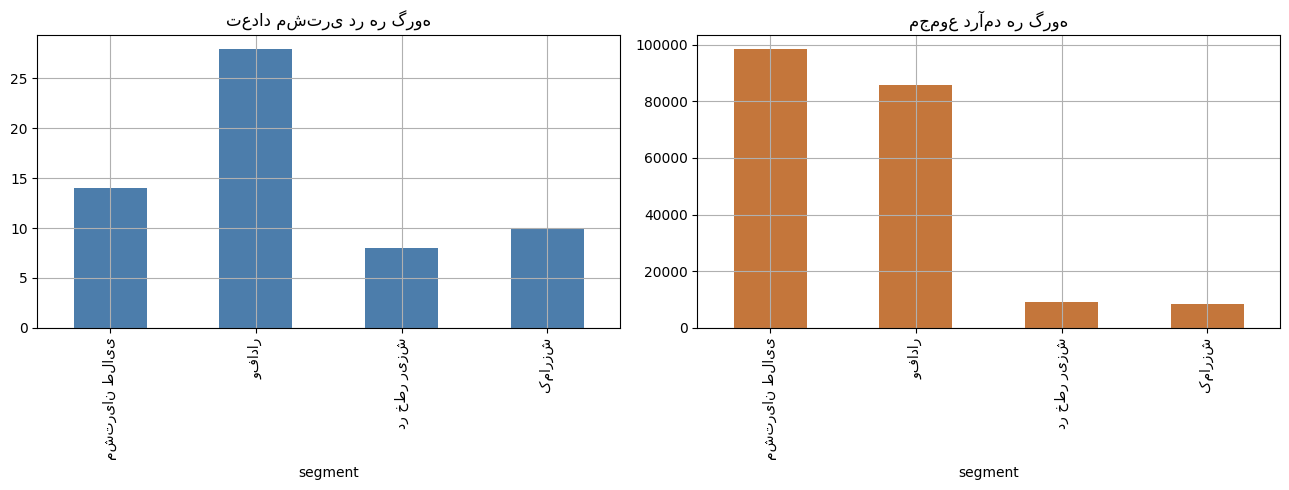

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
segment_summary['تعداد_مشتری'].plot(kind='bar', ax=axes[0], color='#4C7DAB', title='تعداد مشتری در هر گروه')
segment_summary['مجموع_درآمد'].plot(kind='bar', ax=axes[1], color='#C4763B', title='مجموع درآمد هر گروه')
plt.tight_layout()
plt.show()

In [5]:
top_valuable = df.sort_values('total_spending', ascending=False)[
    ['customer_id', 'first_name', 'city', 'segment', 'purchase_count', 'total_spending', 'satisfaction_score']
].head(10)
top_valuable

,customer_id,first_name,city,segment,purchase_count,total_spending,satisfaction_score
43,1044,Mina,Shiraz,مشتریان طلایی,33,14354.34,2
56,1057,Maryam,Ahvaz,مشتریان طلایی,31,13532.74,4
11,1012,Arash,Mashhad,مشتریان طلایی,27,11731.50,2
8,1009,Kimia,Karaj,مشتریان طلایی,34,11615.42,2
58,1059,Ali,Isfahan,مشتریان طلایی,31,8898.55,5
9,1010,Arash,Karaj,وفادار,19,7241.47,1
49,1050,Reza,Mashhad,مشتریان طلایی,30,6198.00,2
3,1004,Sina,Mashhad,مشتریان طلایی,23,6121.45,4
54,1055,Mina,Rasht,وفادار,19,6068.22,1
34,1035,Arash,Tabriz,وفادار,17,5918.21,3


In [6]:
at_risk = df[df['R_score'] == 1].sort_values('total_spending', ascending=False)

print(f'تعداد مشتریان در ریسک ریزش: {len(at_risk)} نفر از {len(df)} مشتری')
print(f'مجموع ارزشی که این گروه تا الان برای شرکت داشتن: {at_risk["total_spending"].sum():,.0f}')
print()
at_risk[['customer_id', 'city', 'last_purchase_days', 'purchase_count',
         'total_spending', 'satisfaction_score', 'segment']].head(10)

تعداد مشتریان در ریسک ریزش: 15 نفر از 60 مشتری
مجموع ارزشی که این گروه تا الان برای شرکت داشتن: 38,758



,customer_id,city,last_purchase_days,purchase_count,total_spending,satisfaction_score,segment
9,1010,Karaj,276,19,7241.47,1,وفادار
34,1035,Tabriz,365,17,5918.21,3,وفادار
52,1053,Tehran,320,18,5805.54,1,وفادار
29,1030,Mashhad,340,26,4079.14,4,وفادار
53,1054,Tabriz,304,9,3691.44,1,در خطر ریزش
6,1007,Rasht,298,29,2237.35,5,وفادار
48,1049,Mashhad,357,23,2140.38,1,وفادار
33,1034,Tabriz,280,29,2117.00,3,وفادار
15,1016,Shiraz,333,11,1497.87,2,در خطر ریزش
18,1019,Shiraz,317,4,1234.88,2,در خطر ریزش


In [7]:
city_stats = df.groupby('city').agg(
    تعداد_مشتری=('customer_id', 'count'),
    مجموع_درآمد=('total_spending', 'sum'),
    میانگین_درآمد_هر_مشتری=('total_spending', 'mean'),
    میانگین_رضایت=('satisfaction_score', 'mean'),
).sort_values('میانگین_درآمد_هر_مشتری', ascending=False)

city_stats.round(2)

,تعداد_مشتری,مجموع_درآمد,میانگین_درآمد_هر_مشتری,میانگین_رضایت
city,,,,
Isfahan,5,21975.32,4395.06,4.40
Mashhad,11,43197.58,3927.05,2.91
Karaj,7,26189.81,3741.40,2.86
Shiraz,6,20715.92,3452.65,2.00
Rasht,5,15168.54,3033.71,2.60
Tabriz,12,36192.49,3016.04,3.00
Ahvaz,8,23384.78,2923.10,3.50
Tehran,6,15161.29,2526.88,2.67


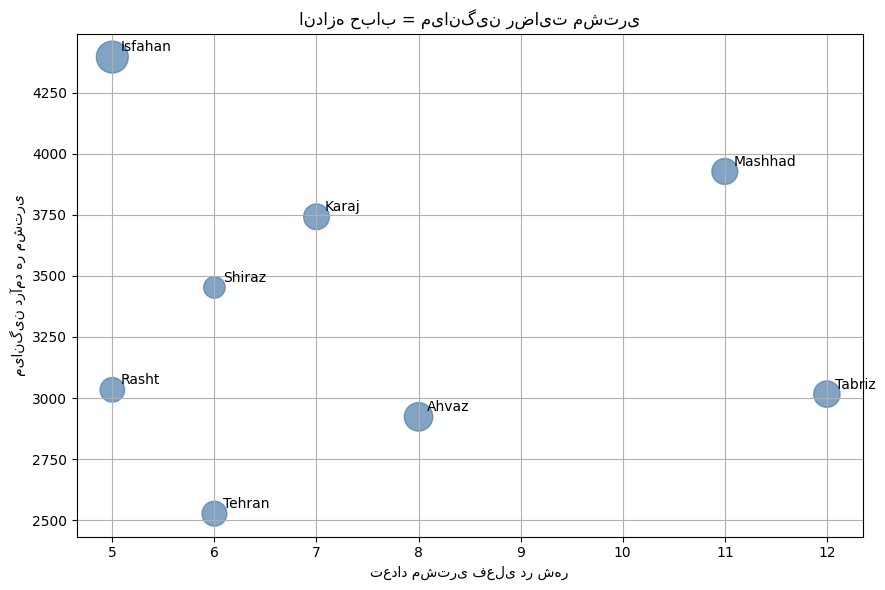

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(city_stats['تعداد_مشتری'], city_stats['میانگین_درآمد_هر_مشتری'],
                      s=city_stats['میانگین_رضایت'] * 120, alpha=0.7, color='#4C7DAB')
for city, row in city_stats.iterrows():
    ax.annotate(city, (row['تعداد_مشتری'], row['میانگین_درآمد_هر_مشتری']),
                textcoords='offset points', xytext=(6, 4))
ax.set_xlabel('تعداد مشتری فعلی در شهر')
ax.set_ylabel('میانگین درآمد هر مشتری')
ax.set_title('اندازه حباب = میانگین رضایت مشتری')
plt.tight_layout()
plt.show()

In [9]:
discount_yes = df[df['discount_used'] == 'Yes']
discount_no = df[df['discount_used'] == 'No']

metrics = ['total_spending', 'purchase_count', 'satisfaction_score']
results = []

for metric in metrics:
    t_stat, p_value = stats.ttest_ind(discount_yes[metric], discount_no[metric], equal_var=False)
    results.append({
        'معیار': metric,
        'میانگین با تخفیف': discount_yes[metric].mean(),
        'میانگین بدون تخفیف': discount_no[metric].mean(),
        'p-value': p_value,
        'اختلاف معنادار (p<0.05)': p_value < 0.05
    })

pd.DataFrame(results).round(3)

,معیار,میانگین با تخفیف,میانگین بدون تخفیف,p-value,اختلاف معنادار (p<0.05)
0,total_spending,2882.174,3736.741,0.297,False
1,purchase_count,17.500,17.294,0.939,False
2,satisfaction_score,3.269,2.765,0.184,False
